## FIRST Decision Tree Regression

### 1. Загружаем необходимые библиотеки и генерируем датасет

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

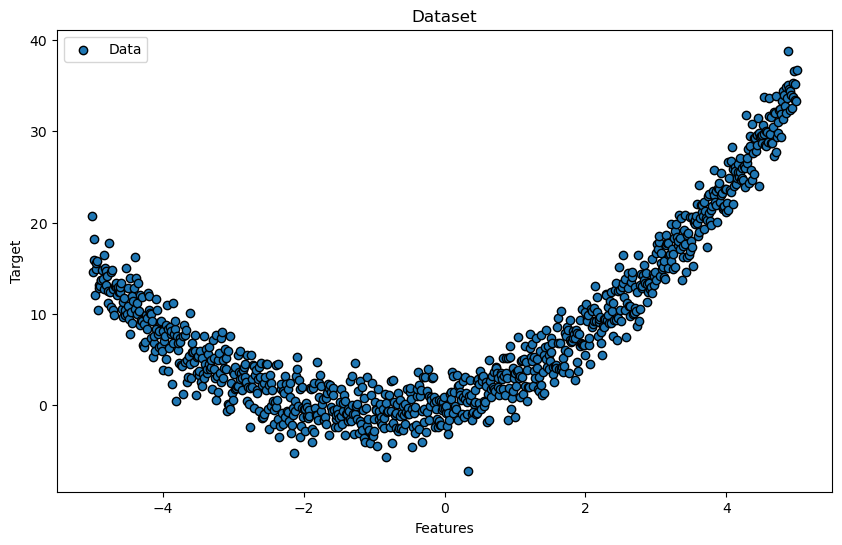

In [2]:
X = np.linspace(-5, 5, 1000)
y = X ** 2 + 2 * X + 2 * np.random.randn(1000)

plt.figure(figsize = (10, 6))
plt.scatter(X, y, edgecolor="black", label="Data")
plt.title("Dataset")
plt.xlabel("Features")
plt.ylabel("Target")
plt.legend()
plt.show()

#### 1.1. Создаем тренировочные и тестовые выборки

In [3]:
X = X.reshape(X.shape[0], 1)
y = y.reshape(y.shape[0], 1)
X_train, X_test, y_train, y_test = train_test_split(X, y)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((750, 1), (250, 1), (750, 1), (250, 1))

### 2. Создаем собственный класс **DecisionTree** для обучения модели дерева решений

In [4]:
class DecisionTree:
    def _init_(model):
        pass
        
    def split_dataset(model, X, y, feature_index, treshold):

        X_right = X[np.where(X[:, feature_index] >= treshold)]
        X_left = X[np.where(X[:, feature_index] < treshold)]
        y_right = y[np.where(X[:, feature_index] >= treshold)]
        y_left = y[np.where(X[:, feature_index] < treshold)]

        splits = {
            "X_right": X_right,
            "X_left": X_left,
            "y_right": y_right,
            "y_left": y_left
        }
        
        return splits

    def cost_with_mse(model, y_left, y_right):
        n_left, n_right = len(y_left), len(y_right)
        n_total = n_right + n_left
        mean_y_right = np.sum(y_right) / n_right
        mean_y_left = np.sum(y_left) / n_left
        
        return (1 / n_total) * (np.sum((mean_y_right - y_right) ** 2) + np.sum((mean_y_left - y_left) ** 2))

    def find_best_split(model, X, y):
        best_index = 0
        best_treshold = X[0, 0]
        best_cost = model.cost_with_mse(model.split_dataset(X, y, 0, best_treshold)["y_left"], model.split_dataset(X, y, 0, best_treshold)["y_right"])

        for i in range(X.shape[1]):
            for j in range(X.shape[0]):
                #y_right, y_left = model.split_dataset(X, y, i, X[j][i])["y_right", "y_left"]
                current_cost = model.cost_with_mse(model.split_dataset(X, y, i, X[j][i])["y_left"], model.split_dataset(X, y, i, X[j][i])["y_right"])
                
                if current_cost < best_cost:
                    best_index = i
                    best_treshold = X[j][i]
                    best_cost = current_cost
            
        best_split_params = dict(
            model.split_dataset(X, y, best_index, best_treshold),
            feature_index = best_index,
            treshold = best_treshold,
            cost = best_cost
        )
        
        return best_split_params

    def build_tree(model, node_dict, current_depth, max_depth, min_samples):
        if len(node_dict["y_left"]) == 0 or len(node_dict["y_right"]) == 0:
            node_dict["left_child"] = node_dict["right_child"] = np.mean(np.append(node_dict["y_left"], node_dict["y_right"]))
            return None
            
        if current_depth >= max_depth:
            node_dict["left_child"] = np.mean(node_dict["y_left"])
            node_dict["right_child"] = np.mean(node_dict["y_right"])
            return None
            
        if node_dict["X_left"].shape[0] <= min_samples:
            node_dict["left_child"] = np.mean(node_dict["y_left"])
            return None
        else:
            node_dict["left_child"] = model.find_best_split(node_dict["X_left"], node_dict["y_left"])
            model.build_tree(node_dict["left_child"], current_depth + 1, max_depth, min_samples)

        if node_dict["X_right"].shape[0] <= min_samples:
            node_dict["right_child"] = np.mean(node_dict["y_right"])
            return None
        else:
            node_dict["right_child"] = model.find_best_split(node_dict["X_right"], node_dict["y_right"])
            model.build_tree(node_dict["right_child"], current_depth + 1, max_depth, min_samples)

        return node_dict
        
    def train(model, X, y, max_depth, min_samples):
        model.tree = model.build_tree(model.find_best_split(X, y), 1, max_depth, min_samples)

    def predict(model, X, node):
        if X[node["feature_index"]] >= node["treshold"]:
            if isinstance(node["right_child"], (float)):
                return node["right_child"]
            else:
                prediction = model.predict(X, node["right_child"])
        else:
            if isinstance(node["left_child"], (float)):
                return node["left_child"]
            else:
                prediction = model.predict(X, node["left_child"])

        return prediction

    def print_tree(model, node, depth = 0):
        if isinstance(node, (float)):
            print(f"{depth * '   '} predicted class: {round(node, 4)}")
        else:
            print(f"{depth * '   '} feature {node['feature_index']} < {round(node['treshold'], 4)}, "
             f"cost of split: {round(node['cost'], 4)}")
            model.print_tree(node["left_child"], depth+1)
            model.print_tree(node["right_child"], depth+1)

#### 2.1. Обучаем модель с глубиной дерева **max_depth = 2**

In [5]:
model_1 = DecisionTree()
model_1.train(X_train, y_train, 2, 40)

C:\Users\Богдан\AppData\Local\Temp\ipykernel_4148\2946706308.py:25: RuntimeWarning: invalid value encountered in scalar divide
  mean_y_left = np.sum(y_left) / n_left


#### 2.1.1. Схема соответсвующего дерева 

In [6]:
model_1.print_tree(model_1.tree)

 feature 0 < 2.9479, cost of split: 28.5932
    feature 0 < -3.8088, cost of split: 18.6029
       predicted class: 10.8179
       predicted class: 3.16
    feature 0 < 4.029, cost of split: 11.6796
       predicted class: 19.2072
       predicted class: 29.3273


#### 2.1.2. **MSE** данного дерева

In [7]:
mse_1 = 0
for i in range(X_test.shape[0]):
    mse_1 = mse_1 + (y_test[i] - model_1.predict(X_test[i], model_1.tree)) ** 2

(1 / y_test.shape[0]) * mse_1

array([14.66135149])

#### 2.2. Обучаем модель с глубиной дерева **max_depth = 3**

In [8]:
model_2 = DecisionTree()
model_2.train(X_train, y_train, 3, 40)

C:\Users\Богдан\AppData\Local\Temp\ipykernel_4148\2946706308.py:25: RuntimeWarning: invalid value encountered in scalar divide
  mean_y_left = np.sum(y_left) / n_left


#### 2.2.1. Схема соответсвующего дерева 

In [9]:
model_2.print_tree(model_2.tree)

 feature 0 < 2.9479, cost of split: 28.5932
    feature 0 < -3.8088, cost of split: 18.6029
       feature 0 < -4.3193, cost of split: 4.898
          predicted class: 12.8673
          predicted class: 8.2049
       feature 0 < 1.5966, cost of split: 8.5253
          predicted class: 1.4206
          predicted class: 9.8308
    feature 0 < 4.029, cost of split: 11.6796
       feature 0 < 3.5385, cost of split: 3.6349
          predicted class: 16.9707
          predicted class: 21.7165
       feature 0 < 4.4695, cost of split: 5.787
          predicted class: 26.2044
          predicted class: 32.1299


#### 2.2.2. **MSE** данного дерева

In [10]:
mse_2 = 0
for i in range(X_test.shape[0]):
    mse_2 = mse_2 + (y_test[i] - model_2.predict(X_test[i], model_2.tree)) ** 2

(1 / y_test.shape[0]) * mse_2

array([6.93691405])

#### 2.3. Визуализация построенных деревьев 

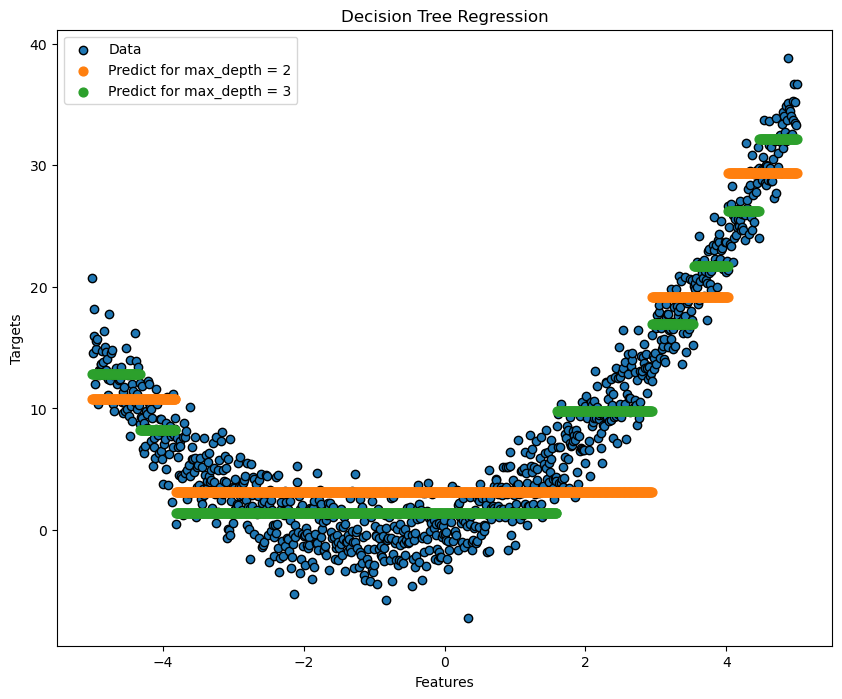

In [11]:
predict_1 = []
for i in range(X.shape[0]):
    result = model_1.predict(X[i], model_1.tree)
    predict_1.append(result)

predict_2 = []
for j in range(X.shape[0]):
    result = model_2.predict(X[j], model_2.tree)
    predict_2.append(result)

plt.figure(figsize = (10, 8))
plt.title("Decision Tree Regression")
plt.scatter(X, y, edgecolor = "black", label = "Data")
plt.scatter(X, predict_1, s = 40, label = "Predict for max_depth = 2")
plt.scatter(X, predict_2, s = 40, label = "Predict for max_depth = 3")
plt.xlabel("Features")
plt.ylabel("Targets")
plt.legend()
plt.show()

### 3. Обучение деревьев решений с помощью библиотеки **scikit-learn**

In [12]:
from sklearn.tree import DecisionTreeRegressor

regr_1 = DecisionTreeRegressor(max_depth = 2)
regr_2 = DecisionTreeRegressor(max_depth = 3)
regr_1.fit(X_train, y_train)
regr_2.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


#### 3.1. **MSE** дерева c **max_depth = 2**

In [13]:
mse_1 = (1 / y_test.shape[0]) * np.sum((y_test - regr_1.predict(X_test).reshape(y_test.shape[0], 1)) ** 2)
mse_1

np.float64(14.66135148973686)

#### 3.2. **MSE** дерева c **max_depth = 3**

In [14]:
mse_2 = (1 / y_test.shape[0]) * np.sum((y_test - regr_2.predict(X_test).reshape(y_test.shape[0], 1)) ** 2)
mse_2

np.float64(6.936914052887443)

#### 3.3. Визуализация построенных деревьев с помощью библиотеки **scikit-learn**

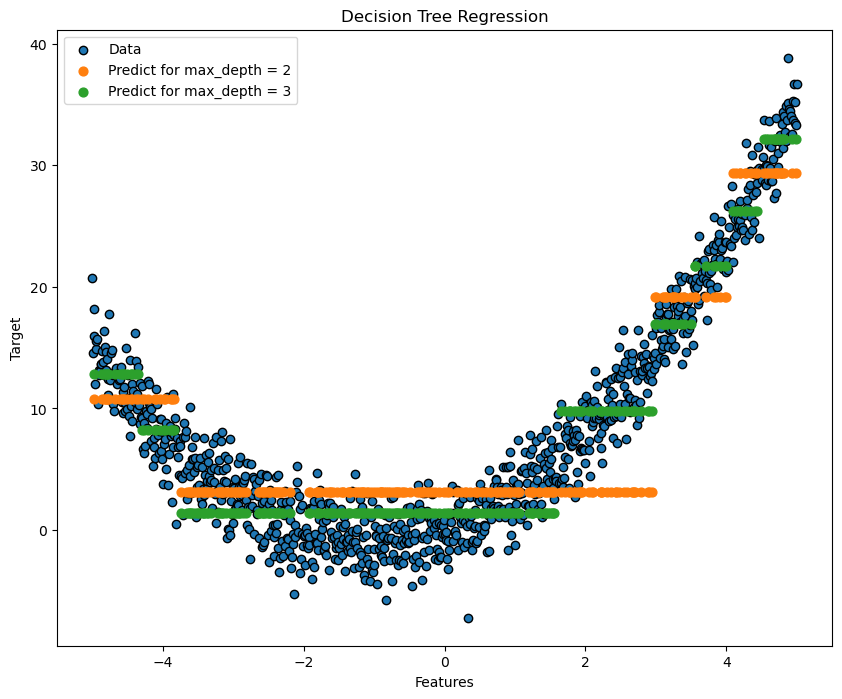

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize = (10, 8))
plt.scatter(X, y, edgecolor="black", label="Data")
plt.scatter(X_test, regr_1.predict(X_test), s = 40, label = "Predict for max_depth = 2")
plt.scatter(X_test, regr_2.predict(X_test), s = 40, label = "Predict for max_depth = 3")
plt.xlabel("Features")
plt.ylabel("Target")
plt.title("Decision Tree Regression")
plt.legend()
plt.show()